# Stage 1: Dataset Preparation

The first stage of the project focuses on distinguishing earthquake signals from background noise.

The INSTANCE dataset provides both earthquake recordings and noise recordings. Before training a machine learning model, the input format, available metadata, and waveform structure need to be established.

This notebook loads the INSTANCE metadata and waveform files and prepares the data for the Stage 1 classification task.

In [2]:
import h5py
import pandas as pd
import numpy as np

# -------------------------
# Paths
# -------------------------

EVENTS_H5 = "../data/sample/data/Instance_events_counts_10k.hdf5"
EVENTS_META = "../data/sample/metadata/metadata_Instance_events_10k.csv"

NOISE_H5 = "../data/sample/data/Instance_noise_1k.hdf5"
NOISE_META = "../data/sample/metadata/metadata_Instance_noise_1k.csv"

# -------------------------
# Load metadata
# -------------------------

events = pd.read_csv(EVENTS_META)
noise = pd.read_csv(NOISE_META)

# -------------------------
# Open waveform files
# -------------------------

events_h5 = h5py.File(EVENTS_H5, "r")
noise_h5 = h5py.File(NOISE_H5, "r")

print("Earthquake traces:", len(events))
print("Noise traces:", len(noise))

Earthquake traces: 10000
Noise traces: 1000


## Inspecting the available P-wave annotations

Each earthquake recording in the INSTANCE dataset contains an annotated P-wave arrival sample.

For the initial Stage 1 dataset, a fixed-length window is extracted around the P-wave arrival. Before extracting these windows, the available P-wave arrivals are checked to ensure that sufficient waveform data exists before and after each arrival.

The planned window contains 5 seconds before the P-wave arrival and 15 seconds after it, giving a total duration of 20 seconds.

In [3]:
p_times = events["trace_P_arrival_sample"] * events["trace_dt_s"]

print("Minimum P arrival:", p_times.min())
print("Maximum P arrival:", p_times.max())

suitable = (p_times >= 5) & (p_times <= 105)

print(
    "P arrivals suitable for a 20 s window:",
    suitable.sum()
)

Minimum P arrival: 14.57
Maximum P arrival: 67.01
P arrivals suitable for a 20 s window: 10000


## Defining the Stage 1 input

Each sample contains all three components of the seismic recording.

The waveforms are sampled at 100 Hz, so a 20-second window contains 2,000 samples per component.

The resulting input has the shape:

3 components × 2,000 samples

Using all three components preserves the directional information contained in the seismic recording rather than reducing the input to a single component.

## Selecting earthquake recordings

The P-wave arrival provided in the INSTANCE metadata is used as the reference point for extracting a fixed-length window.

Each sample contains 5 seconds of waveform before the annotated P-wave arrival and 15 seconds after it, giving a total duration of 20 seconds. This provides background context before the event as well as the seismic signal following the P-wave arrival.

Only recordings with a valid P-wave arrival and sufficient data on both sides of the arrival are included.

In [4]:
# Keep earthquake recordings with a valid P arrival
# and enough samples for the 20-second window.

window_before_s = 5
window_after_s = 15
window_duration_s = window_before_s + window_after_s

valid_p = (
    events["trace_P_arrival_sample"].notna()
    & (events["trace_P_arrival_sample"] >= window_before_s / events["trace_dt_s"])
    & (
        events["trace_P_arrival_sample"]
        <= events["trace_npts"] - window_after_s / events["trace_dt_s"]
    )
)

earthquake_samples = events.loc[valid_p].copy()

print("Total earthquake recordings:", len(events))
print("Usable earthquake recordings:", len(earthquake_samples))
print("Window duration:", window_duration_s, "seconds")

Total earthquake recordings: 10000
Usable earthquake recordings: 10000
Window duration: 20 seconds


## Extracting one earthquake sample

A single earthquake recording is first used to verify the window extraction procedure.

The P-wave arrival is stored as a sample index in the metadata. The corresponding time window is converted to sample indices and extracted consistently across all three components.

In [5]:
# Extract one example earthquake window

row = earthquake_samples.iloc[0]

trace_name = row["trace_name"]
p_sample = int(row["trace_P_arrival_sample"])
npts = int(row["trace_npts"])

# Convert the window length from seconds to samples
dt = float(row["trace_dt_s"])

before_samples = int(window_before_s / dt)
after_samples = int(window_after_s / dt)

start_sample = p_sample - before_samples
end_sample = p_sample + after_samples

waveform = events_h5["data"][trace_name][:]

earthquake_window = waveform[:, start_sample:end_sample]

print("Trace:", trace_name)
print("Original shape:", waveform.shape)
print("Window shape:", earthquake_window.shape)
print("P sample in original trace:", p_sample)
print("P sample inside window:", before_samples)

Trace: 11030611.IV.OFFI..HH
Original shape: (3, 12000)
Window shape: (3, 2000)
P sample in original trace: 1735
P sample inside window: 500


## Inspecting the extracted earthquake window

The extracted 20-second window is plotted to verify the window boundaries and the position of the annotated P-wave arrival.

The P-wave should occur 5 seconds after the beginning of the window. All three components are plotted using a common time axis.

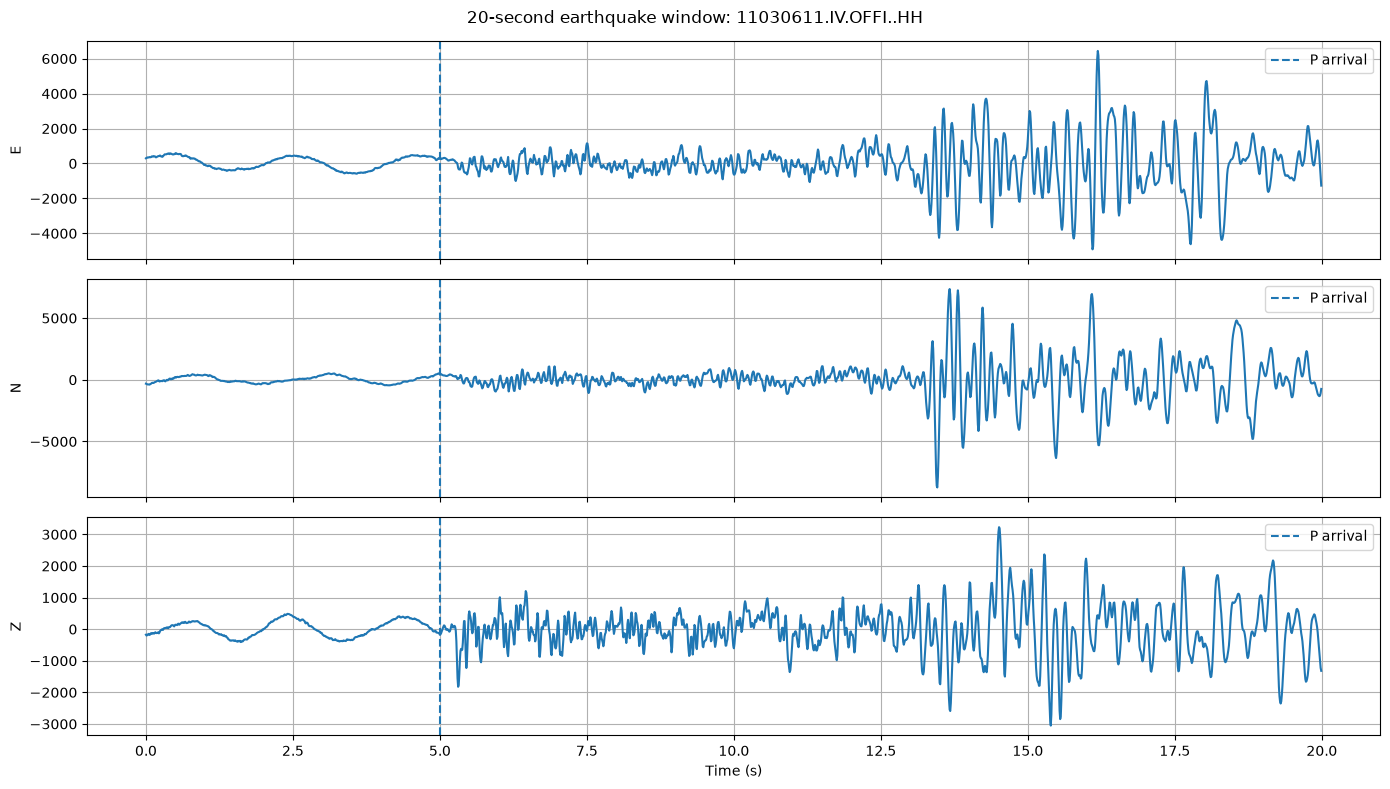

In [6]:
# Create a time axis for the extracted 20-second window
import matplotlib.pyplot as plt

window_time = np.arange(earthquake_window.shape[1]) * dt

# P arrival relative to the extracted window
p_time_in_window = before_samples * dt

component_names = ["E", "N", "Z"]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(window_time, earthquake_window[i])
    ax.axvline(
        p_time_in_window,
        linestyle="--",
        label="P arrival"
    )
    ax.set_ylabel(component_names[i])
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"20-second earthquake window: {trace_name}")

plt.tight_layout()
plt.show()

## Creating earthquake samples

The validated windowing procedure is applied to the earthquake recordings with valid P-wave arrivals.

In [7]:
def extract_earthquake_window(row, before_s=5, after_s=15):
    trace_name = row["trace_name"]

    dt = float(row["trace_dt_s"])
    p_sample = int(row["trace_P_arrival_sample"])

    before_samples = int(before_s / dt)
    after_samples = int(after_s / dt)

    start = p_sample - before_samples
    end = p_sample + after_samples

    waveform = events_h5["data"][trace_name][:]

    return waveform[:, start:end]


# Test the extraction function on the first usable recording
test_window = extract_earthquake_window(earthquake_samples.iloc[0])

print("Window shape:", test_window.shape)

Window shape: (3, 2000)


## Selecting noise windows

The noise recordings do not contain an annotated P-wave arrival. A 20-second segment is therefore extracted from each selected noise recording.

The noise segment has the same dimensions as an earthquake sample: 3 components × 2,000 samples.

A random start position is used so that the classifier does not learn a fixed temporal position within the noise recordings.

In [8]:
def extract_noise_window(row, window_s=20):
    trace_name = row["trace_name"]

    dt = float(row["trace_dt_s"])
    npts = int(row["trace_npts"])

    window_samples = int(window_s / dt)

    if npts < window_samples:
        raise ValueError(
            f"Trace {trace_name} is shorter than {window_s} seconds."
        )

    # Random starting position
    max_start = npts - window_samples
    start = np.random.randint(0, max_start + 1)
    end = start + window_samples

    waveform = noise_h5["data"][trace_name][:]

    return waveform[:, start:end]

#  Verifying a noise sample

np.random.seed(42)

test_noise_window = extract_noise_window(noise.iloc[0])

print("Noise window shape:", test_noise_window.shape)

Noise window shape: (3, 2000)


## Creating the Stage 1 Dataset

The Stage 1 dataset contains two classes:

- Earthquake windows centered on the annotated P-wave arrival.
- Noise windows extracted from noise recordings.

Both classes use the same input dimensions of 3 components × 2,000 samples.

Each sample is assigned a binary label:

- `1` for earthquake
- `0` for noise

The dataset contains 500 earthquake windows and 500 noise windows. This subset is used during pipeline development before scaling the experiments to a larger portion of the INSTANCE dataset.

In [9]:
# Number of samples for the initial dataset
n_earthquake = 500
n_noise = 500

# Reproducible selection of earthquake recordings
earthquake_selected = earthquake_samples.sample(
    n=n_earthquake,
    random_state=42
).reset_index(drop=True)

# Reproducible selection of noise recordings
noise_selected = noise.sample(
    n=n_noise,
    random_state=42
).reset_index(drop=True)

print("Earthquake recordings:", len(earthquake_selected))
print("Noise recordings:", len(noise_selected))

Earthquake recordings: 500
Noise recordings: 500


## Extracting the initial Stage 1 dataset

The selected recordings are converted into fixed-size waveform samples using the extraction functions defined above.

Earthquake samples are centered on the annotated P-wave arrival. Noise samples use randomly positioned 20-second segments.

The resulting arrays are stored together with their labels and source identifiers.

In [10]:
X = []
y = []
source_ids = []
trace_names = []

# Earthquake samples
for _, row in earthquake_selected.iterrows():

    window = extract_earthquake_window(row)

    assert window.shape == (3, 2000)

    X.append(window)
    y.append(1)
    source_ids.append(row["source_id"])
    trace_names.append(row["trace_name"])


# Noise samples
np.random.seed(42)

for _, row in noise_selected.iterrows():

    window = extract_noise_window(row)

    assert window.shape == (3, 2000)

    X.append(window)
    y.append(0)

    # Noise has no earthquake source event
    source_ids.append(None)
    trace_names.append(row["trace_name"])


X = np.stack(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Earthquake samples:", np.sum(y == 1))
print("Noise samples:", np.sum(y == 0))

# Create a metadata table for the extracted samples
sample_metadata = pd.DataFrame({
    "trace_name": trace_names,
    "source_id": source_ids,
    "label": y
})

print("Waveform data shape:", X.shape)
print("Metadata shape:", sample_metadata.shape)
print()
print(sample_metadata.head())

X shape: (1000, 3, 2000)
y shape: (1000,)
Earthquake samples: 500
Noise samples: 500
Waveform data shape: (1000, 3, 2000)
Metadata shape: (1000, 3)

              trace_name   source_id  label
0  11190131.IV.T1217..EH  11190131.0      1
1     1115611.MN.BNI..HL   1115611.0      1
2    11072811.IV.EL6..EH  11072811.0      1
3  11158391.IV.T1241..EH  11158391.0      1
4   11151081.IV.MMO1..EH  11151081.0      1


## Splitting the dataset by earthquake event

The INSTANCE dataset may contain multiple station recordings for the same earthquake event. Randomly splitting individual waveform samples could therefore place recordings from the same event in both the training and test sets.

To reduce this form of data leakage, earthquake samples are assigned to the same dataset based on their `source_id`. Noise samples do not have an earthquake source identifier and can be split independently.

In [11]:
from sklearn.model_selection import GroupShuffleSplit

# Indices of earthquake samples
earthquake_indices = np.where(y == 1)[0]

# Source ID for each earthquake sample
earthquake_source_ids = np.array(
    [source_ids[i] for i in earthquake_indices]
)

# First split: 70% train, 30% temporary
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx_rel, temp_idx_rel = next(
    gss.split(
        earthquake_indices,
        groups=earthquake_source_ids
    )
)

train_earthquake_indices = earthquake_indices[train_idx_rel]
temp_earthquake_indices = earthquake_indices[temp_idx_rel]

# Second split: half validation, half test
temp_source_ids = np.array(
    [source_ids[i] for i in temp_earthquake_indices]
)

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx_rel, test_idx_rel = next(
    gss_test.split(
        temp_earthquake_indices,
        groups=temp_source_ids
    )
)

val_earthquake_indices = temp_earthquake_indices[val_idx_rel]
test_earthquake_indices = temp_earthquake_indices[test_idx_rel]

print("Earthquake training samples:", len(train_earthquake_indices))
print("Earthquake validation samples:", len(val_earthquake_indices))
print("Earthquake test samples:", len(test_earthquake_indices))

Earthquake training samples: 342
Earthquake validation samples: 76
Earthquake test samples: 82


## Splitting noise samples

Noise recordings do not correspond to earthquake source events, so the noise samples can be divided independently.

The same 70% / 15% / 15% proportions are used to maintain a balanced class distribution across the three subsets.

In [12]:
noise_indices = np.where(y == 0)[0]

rng = np.random.default_rng(42)
rng.shuffle(noise_indices)

n_train_noise = int(0.70 * len(noise_indices))
n_val_noise = int(0.15 * len(noise_indices))

train_noise_indices = noise_indices[:n_train_noise]

val_noise_indices = noise_indices[
    n_train_noise:n_train_noise + n_val_noise
]

test_noise_indices = noise_indices[
    n_train_noise + n_val_noise:
]

print("Noise training samples:", len(train_noise_indices))
print("Noise validation samples:", len(val_noise_indices))
print("Noise test samples:", len(test_noise_indices))

Noise training samples: 350
Noise validation samples: 75
Noise test samples: 75


## Creating the train, validation, and test sets

The dataset indices generated in the previous step are combined for earthquake and noise samples.

The resulting subsets contain waveform data and their corresponding class labels. The earthquake source identifiers are retained separately so that event-level separation can be verified.

No preprocessing parameters are estimated at this stage.

In [13]:
# Combine earthquake and noise indices for each subset

train_indices = np.concatenate([
    train_earthquake_indices,
    train_noise_indices
])

val_indices = np.concatenate([
    val_earthquake_indices,
    val_noise_indices
])

test_indices = np.concatenate([
    test_earthquake_indices,
    test_noise_indices
])

# Shuffle each subset so earthquake and noise samples are mixed

rng = np.random.default_rng(42)

rng.shuffle(train_indices)
rng.shuffle(val_indices)
rng.shuffle(test_indices)

# Create the actual datasets

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[val_indices]
y_val = y[val_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print()
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (692, 3, 2000)
X_val:   (151, 3, 2000)
X_test:  (157, 3, 2000)

y_train: (692,)
y_val:   (151,)
y_test:  (157,)


## Verifying event-level separation

Because multiple stations can record the same earthquake, source identifiers are checked to ensure that earthquake events assigned to the training set do not also occur in the test set.

This prevents recordings from the same physical event from appearing on both sides of the evaluation.

In [14]:
train_source_ids = set(
    sample_metadata.iloc[train_indices]
    .loc[lambda df: df["label"] == 1, "source_id"]
)

test_source_ids = set(
    sample_metadata.iloc[test_indices]
    .loc[lambda df: df["label"] == 1, "source_id"]
)

overlap = train_source_ids.intersection(test_source_ids)

print("Training earthquake events:", len(train_source_ids))
print("Test earthquake events:", len(test_source_ids))
print("Events appearing in both:", len(overlap))

Training earthquake events: 137
Test earthquake events: 30
Events appearing in both: 0


## Preprocessing the waveform data

The waveform samples are preprocessed before model training.

The first step is constant detrending, which removes the mean amplitude from each component independently. This reduces constant baseline offsets while preserving the time-varying seismic signal.

The preprocessing is applied separately to each waveform component.

In [15]:
from scipy import signal

def detrend_waveforms(X):
    """
    Remove the constant mean from each component of each waveform.

    Parameters
    ----------
    X : np.ndarray
        Waveform array with shape (n_samples, n_components, n_timesteps).

    Returns
    -------
    np.ndarray
        Detrended waveform array with the same shape as X.
    """
    X_detrended = signal.detrend(
        X,
        axis=-1,
        type="constant"
    )

    return X_detrended

## Applying detrending to each dataset

The detrending operation is applied to the training, validation, and test sets using the same transformation.

Unlike normalization, constant detrending does not require parameters to be estimated from the training set. Each waveform component has its own mean removed independently.

In [16]:
X_train_detrended = detrend_waveforms(X_train)
X_val_detrended = detrend_waveforms(X_val)
X_test_detrended = detrend_waveforms(X_test)

print("X_train:", X_train_detrended.shape)
print("X_val:", X_val_detrended.shape)
print("X_test:", X_test_detrended.shape)

X_train: (692, 3, 2000)
X_val: (151, 3, 2000)
X_test: (157, 3, 2000)


## Bandpass filtering

A bandpass filter is used to retain a selected range of frequencies while attenuating frequencies outside that range.

For the development dataset, a 3–20 Hz bandpass filter is used as an initial configuration. This is a starting point for the preprocessing pipeline rather than a final optimized frequency range.

The same filter is applied to all three seismic components and to the training, validation, and test sets.

In [17]:
from scipy.signal import butter, sosfiltfilt

# Sampling frequency
fs = 100.0

# Initial filter configuration
lowcut = 3.0
highcut = 20.0

# Butterworth bandpass filter
sos = butter(
    4,
    [lowcut, highcut],
    btype="bandpass",
    fs=fs,
    output="sos"
)


def bandpass_filter(X):
    """
    Apply a zero-phase bandpass filter to each waveform component.

    Parameters
    ----------
    X : np.ndarray
        Waveform array with shape
        (n_samples, n_components, n_timesteps).

    Returns
    -------
    np.ndarray
        Filtered waveform array with the same shape.
    """
    return sosfiltfilt(sos, X, axis=-1)

## Applying the bandpass filter

The same filter configuration is applied independently to every waveform component.

Zero-phase filtering is used so that the filtering operation does not introduce a time shift in the waveform. Preserving the timing of seismic arrivals is important for later P-wave detection and picking.

In [18]:
X_train_filtered = bandpass_filter(X_train_detrended)
X_val_filtered = bandpass_filter(X_val_detrended)
X_test_filtered = bandpass_filter(X_test_detrended)

print("X_train:", X_train_filtered.shape)
print("X_val:", X_val_filtered.shape)
print("X_test:", X_test_filtered.shape)

X_train: (692, 3, 2000)
X_val: (151, 3, 2000)
X_test: (157, 3, 2000)


## Normalizing waveform amplitudes

The filtered waveform amplitudes are standardized so that differences in absolute scale do not dominate the machine learning model.

The mean and standard deviation are estimated from the training set only. These training statistics are then applied unchanged to the validation and test sets to prevent information from the evaluation data from influencing preprocessing.

In [19]:
# Calculate normalization parameters from the training set only

train_mean = X_train_filtered.mean()
train_std = X_train_filtered.std()

print("Training mean:", train_mean)
print("Training standard deviation:", train_std)

Training mean: 0.057676392740808075
Training standard deviation: 17140.697656104086


## Applying the training-set normalization

The training-set mean and standard deviation are used to transform all three dataset splits.

No separate normalization parameters are calculated for the validation or test sets.

In [20]:
X_train_processed = (
    X_train_filtered - train_mean
) / train_std

X_val_processed = (
    X_val_filtered - train_mean
) / train_std

X_test_processed = (
    X_test_filtered - train_mean
) / train_std

print("Train mean after normalization:", X_train_processed.mean())
print("Train std after normalization:", X_train_processed.std())

Train mean after normalization: 1.8396759174906254e-19
Train std after normalization: 1.0


## Calculating signal-to-noise ratio

Signal-to-noise ratio (SNR) measures how strongly the earthquake signal stands out from the background noise.

For the earthquake windows, the 5 seconds before the annotated P-wave arrival are used as the noise reference. The first 3 seconds following the P-wave arrival are used as the signal window.

SNR is calculated separately for the three seismic components using RMS amplitude and expressed in decibels. The median component SNR is retained as a representative value for each earthquake sample.

In [21]:
def rms(signal):
    """Calculate the root-mean-square amplitude."""
    return np.sqrt(np.mean(signal ** 2))


def calculate_snr(window, p_sample_in_window, fs=100.0):
    """
    Calculate component-wise SNR for an earthquake window.

    Parameters
    ----------
    window : np.ndarray
        Waveform with shape (3, n_samples).
    p_sample_in_window : int
        P-wave sample index within the extracted window.
    fs : float
        Sampling frequency in Hz.

    Returns
    -------
    component_snr_db : np.ndarray
        SNR in dB for E, N and Z components.
    """
    noise_samples = int(5 * fs)
    signal_samples = int(3 * fs)

    noise_start = 0
    noise_end = p_sample_in_window

    signal_start = p_sample_in_window
    signal_end = p_sample_in_window + signal_samples

    if signal_end > window.shape[1]:
        raise ValueError("Signal window extends beyond waveform.")

    snr_values = []

    for component in range(3):
        noise_rms = rms(window[component, noise_start:noise_end])
        signal_rms = rms(window[component, signal_start:signal_end])

        if noise_rms == 0:
            snr_db = np.inf
        else:
            snr_db = 20 * np.log10(signal_rms / noise_rms)

        snr_values.append(snr_db)

    return np.array(snr_values)

In [22]:
earthquake_snr = []

for _, row in earthquake_selected.iterrows():

    window = extract_earthquake_window(row)

    p_sample_in_window = before_samples

    snr_components = calculate_snr(
        window,
        p_sample_in_window,
        fs=100.0
    )

    earthquake_snr.append({
        "trace_name": row["trace_name"],
        "source_id": row["source_id"],
        "snr_E_db": snr_components[0],
        "snr_N_db": snr_components[1],
        "snr_Z_db": snr_components[2],
        "snr_median_db": np.median(snr_components)
    })

earthquake_snr = pd.DataFrame(earthquake_snr)

print("Number of earthquake samples:", len(earthquake_snr))

/tmp/ipykernel_46617/1783910144.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.mean(signal ** 2))


Number of earthquake samples: 500


## Inspecting the SNR distribution

The distribution of SNR values provides an indication of the range of signal quality present in the earthquake recordings.

Higher SNR values indicate a clearer separation between the earthquake signal and the pre-event background. Lower values indicate more difficult detection conditions.

In [23]:
print(
    earthquake_snr["snr_median_db"].describe()
)

count    499.000000
mean      15.308352
std       13.755566
min       -7.048315
25%        4.237248
50%       11.903318
75%       23.908038
max       66.919323
Name: snr_median_db, dtype: float64


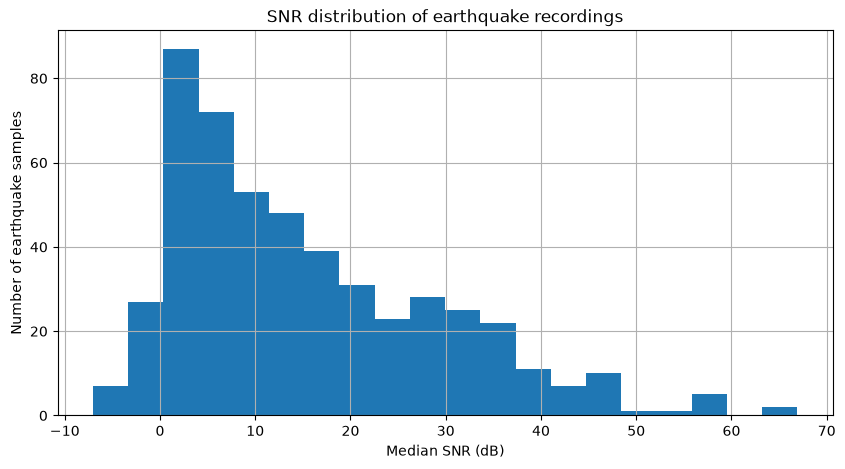

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    earthquake_snr["snr_median_db"],
    bins=20
)

plt.xlabel("Median SNR (dB)")
plt.ylabel("Number of earthquake samples")
plt.title("SNR distribution of earthquake recordings")
plt.grid(True)

plt.show()

## Stage 1: STA/LTA earthquake versus noise baseline

STA/LTA is used as a traditional baseline for the Stage 1 classification task.

For each 20-second waveform window, the processed Z component is passed through the STA/LTA trigger. A window is classified as an earthquake if at least one STA/LTA trigger is produced.

The annotated P-wave arrival is not used during detection. It is only available as ground truth metadata and is reserved for later P-wave picking evaluation.

In [25]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# STA/LTA parameters
sta_seconds = 1.0
lta_seconds = 10.0

thr_on = 3.0
thr_off = 1.5

fs = 100.0

sta_samples = int(sta_seconds * fs)
lta_samples = int(lta_seconds * fs)

## Applying STA/LTA to the development dataset

The Short-Term Average / Long-Term Average (STA/LTA) method is used as a traditional baseline for detecting changes in seismic signal energy.

The STA/LTA characteristic function compares the short-term signal energy with the long-term background energy:

$$
R(t) = \frac{STA(t)}{LTA(t)}
$$

A trigger begins when the ratio exceeds the trigger-on threshold and ends when it falls below the trigger-off threshold.

For this baseline, the Z component is used as the input signal. A waveform is classified as an earthquake when at least one STA/LTA trigger occurs within the 20-second window.

The trigger-on threshold is set to 3.0 and the trigger-off threshold to 1.5 for this development experiment.

In [26]:
def sta_lta_predict(X):
    """
    Classify waveform windows using STA/LTA.

    Parameters
    ----------
    X : np.ndarray
        Waveform array with shape
        (n_samples, 3, n_timesteps).

    Returns
    -------
    predictions : np.ndarray
        Binary predictions:
        1 = trigger detected
        0 = no trigger detected
    """
    predictions = []

    for sample in X:

        # Z component
        z = sample[2]

        characteristic = classic_sta_lta(
            z,
            sta_samples,
            lta_samples
        )

        triggers = trigger_onset(
            characteristic,
            thr_on,
            thr_off
        )

        predictions.append(1 if len(triggers) > 0 else 0)

    return np.array(predictions)

## Generating baseline predictions

The same detection parameters are applied to the training, validation, and test sets. The test set is not used to tune these parameters.

In [27]:
y_train_sta = sta_lta_predict(X_train_processed)
y_val_sta = sta_lta_predict(X_val_processed)
y_test_sta = sta_lta_predict(X_test_processed)

print("Train predictions:", len(y_train_sta))
print("Validation predictions:", len(y_val_sta))
print("Test predictions:", len(y_test_sta))

Train predictions: 692
Validation predictions: 151
Test predictions: 157


## Evaluating the STA/LTA baseline

The baseline predictions are compared with the true earthquake and noise labels.

Accuracy is reported together with precision, recall, and F1-score because a detector can achieve a reasonable accuracy while still producing many false alarms.

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_test_sta)
precision = precision_score(y_test, y_test_sta, zero_division=0)
recall = recall_score(y_test, y_test_sta, zero_division=0)
f1 = f1_score(y_test, y_test_sta, zero_division=0)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_sta))

Accuracy:  0.771
Precision: 0.848
Recall:    0.683
F1-score:  0.757

Confusion matrix:
[[65 10]
 [26 56]]


## Saving the Stage 1 development dataset

In [29]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    processed_dir / "stage1_development_rf.npz",
    X_train=X_train_filtered,
    y_train=y_train,
    X_val=X_val_filtered,
    y_val=y_val,
    X_test=X_test_filtered,
    y_test=y_test
)

print("Saved Random Forest development dataset.")

Saved Random Forest development dataset.


## Creating the full Stage 1 dataset

The development dataset was used to validate the dataset construction and preprocessing pipeline.

The full Stage 1 dataset uses all available earthquake and noise recordings in the INSTANCE sample dataset that satisfy the windowing requirements.

Each earthquake recording contributes one 20-second window centered on the annotated P-wave arrival. Each noise recording contributes one 20-second window selected from the recording.

The resulting dataset is used for the main Stage 1 experiments.

In [30]:
# Select all usable earthquake recordings
# and all available noise recordings.

earthquake_full = earthquake_samples.reset_index(drop=True)
noise_full = noise.reset_index(drop=True)

print("Usable earthquake recordings:", len(earthquake_full))
print("Available noise recordings:", len(noise_full))

Usable earthquake recordings: 10000
Available noise recordings: 1000


## Preparing the full Stage 1 dataset

The full INSTANCE sample dataset is processed without storing all waveform windows in memory simultaneously.

Metadata and dataset indices are prepared first. Waveform windows are then extracted and saved by dataset split to reduce memory usage during processing.

In [31]:
# Full earthquake and noise recordings

earthquake_full = earthquake_samples.reset_index(drop=True)
noise_full = noise.reset_index(drop=True)

print("Usable earthquake recordings:", len(earthquake_full))
print("Available noise recordings:", len(noise_full))

Usable earthquake recordings: 10000
Available noise recordings: 1000


In [32]:
from sklearn.model_selection import GroupShuffleSplit

# Earthquake indices and source IDs
eq_indices = np.arange(len(earthquake_full))
eq_source_ids = earthquake_full["source_id"].to_numpy()

# 70% training, 30% temporary
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

eq_train_rel, eq_temp_rel = next(
    gss.split(eq_indices, groups=eq_source_ids)
)

eq_train_full = eq_indices[eq_train_rel]
eq_temp_full = eq_indices[eq_temp_rel]

# 15% validation, 15% test
temp_source_ids = eq_source_ids[eq_temp_full]

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

eq_val_rel, eq_test_rel = next(
    gss_test.split(eq_temp_full, groups=temp_source_ids)
)

eq_val_full = eq_temp_full[eq_val_rel]
eq_test_full = eq_temp_full[eq_test_rel]

print("Earthquake train:", len(eq_train_full))
print("Earthquake validation:", len(eq_val_full))
print("Earthquake test:", len(eq_test_full))

Earthquake train: 6761
Earthquake validation: 1593
Earthquake test: 1646


In [33]:
noise_indices = np.arange(len(noise_full))

rng = np.random.default_rng(42)
rng.shuffle(noise_indices)

n_train_noise = int(0.70 * len(noise_indices))
n_val_noise = int(0.15 * len(noise_indices))

noise_train_full = noise_indices[:n_train_noise]
noise_val_full = noise_indices[
    n_train_noise:n_train_noise + n_val_noise
]
noise_test_full = noise_indices[
    n_train_noise + n_val_noise:
]

print("Noise train:", len(noise_train_full))
print("Noise validation:", len(noise_val_full))
print("Noise test:", len(noise_test_full))

Noise train: 700
Noise validation: 150
Noise test: 150


## Creating full-data split metadata

The waveform extraction stage uses a metadata table containing the original trace identifiers, class labels, source identifiers, and dataset split.

This allows waveform windows to be processed incrementally without loading the complete dataset into memory.

In [34]:
# Build metadata records

split_records = []

for idx in eq_train_full:
    row = earthquake_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": row["source_id"],
        "label": 1,
        "split": "train"
    })

for idx in eq_val_full:
    row = earthquake_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": row["source_id"],
        "label": 1,
        "split": "validation"
    })

for idx in eq_test_full:
    row = earthquake_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": row["source_id"],
        "label": 1,
        "split": "test"
    })

for idx in noise_train_full:
    row = noise_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": None,
        "label": 0,
        "split": "train"
    })

for idx in noise_val_full:
    row = noise_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": None,
        "label": 0,
        "split": "validation"
    })

for idx in noise_test_full:
    row = noise_full.iloc[idx]
    split_records.append({
        "trace_name": row["trace_name"],
        "source_id": None,
        "label": 0,
        "split": "test"
    })

full_split_metadata = pd.DataFrame(split_records)

print(full_split_metadata["split"].value_counts())
print()
print(full_split_metadata["label"].value_counts())

split
train         7461
test          1796
validation    1743
Name: count, dtype: int64

label
1    10000
0     1000
Name: count, dtype: int64


In [35]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

full_split_metadata.to_csv(
    processed_dir / "stage1_full_split_metadata.csv",
    index=False
)

print("Saved full-data split metadata.")

Saved full-data split metadata.


## Extracting and preprocessing the full waveform splits

The waveform windows are extracted from the HDF5 files using the split metadata created above.

Each window contains 5 seconds before and 15 seconds after the annotated P arrival for earthquake recordings, or a randomly selected 20-second segment for noise recordings.

The waveforms are detrended and bandpass filtered before being saved. Each split is processed separately to limit memory usage.

In [36]:
from pathlib import Path
from scipy import signal

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

fs = 100.0

# 3–20 Hz candidate bandpass used for the current pipeline
sos = signal.butter(
    4,
    [3.0, 20.0],
    btype="bandpass",
    fs=fs,
    output="sos"
)


def preprocess_waveform(window):
    """
    Detrend and bandpass-filter a 3-component waveform.
    """
    window = signal.detrend(
        window,
        axis=-1,
        type="constant"
    )

    window = signal.sosfiltfilt(
        sos,
        window,
        axis=-1
    )

    return window.astype(np.float32)

## Processing the training, validation, and test splits

Each split is processed independently and stored as a compressed NumPy array.

The full waveform dataset is not held in memory at once.

In [37]:
def process_split(split_name):
    split_meta = full_split_metadata[
        full_split_metadata["split"] == split_name
    ].reset_index(drop=True)

    X_split = []
    y_split = []

    for _, row in split_meta.iterrows():

        trace_name = row["trace_name"]
        label = int(row["label"])

        if label == 1:
            event_row = earthquake_full[
                earthquake_full["trace_name"] == trace_name
            ].iloc[0]

            window = extract_earthquake_window(event_row)

        else:
            noise_row = noise_full[
                noise_full["trace_name"] == trace_name
            ].iloc[0]

            window = extract_noise_window(
                noise_row,
                window_s=20
            )

        if window.shape != (3, 2000):
            raise ValueError(
                f"Unexpected shape for {trace_name}: {window.shape}"
            )

        window = preprocess_waveform(window)

        X_split.append(window)
        y_split.append(label)

    X_split = np.stack(X_split).astype(np.float32)
    y_split = np.array(y_split, dtype=np.int8)

    np.save(
        processed_dir / f"stage1_full_{split_name}_X.npy",
        X_split
    )

    np.save(
        processed_dir / f"stage1_full_{split_name}_y.npy",
        y_split
    )

    print(
        f"{split_name}: "
        f"X={X_split.shape}, "
        f"y={y_split.shape}"
    )

In [38]:
process_split("train")
process_split("validation")
process_split("test")

train: X=(7461, 3, 2000), y=(7461,)
validation: X=(1743, 3, 2000), y=(1743,)
test: X=(1796, 3, 2000), y=(1796,)


## Full-data STA/LTA baseline

The STA/LTA baseline is evaluated on the held-out test split of the full Stage 1 dataset. A waveform is classified as an earthquake when the STA/LTA characteristic function produces at least one trigger within the evaluation window.

The baseline uses a 1 s short-term window, a 10 s long-term window, an ON threshold of 3.0, and an OFF threshold of 1.5.

In [42]:
X_test_full = np.load(
    "../data/processed/stage1_full_test_X.npy"
)

y_test_full = np.load(
    "../data/processed/stage1_full_test_y.npy"
)

print("X_test_full:", X_test_full.shape)
print("y_test_full:", y_test_full.shape)

fs = 100.0

nsta = int(1.0 * fs)
nlta = int(10.0 * fs)

threshold_on = 3.0
threshold_off = 1.5

y_test_sta_lta = []

for waveform in X_test_full:

    # Use Z component for the STA/LTA baseline
    z = waveform[2]

    characteristic = classic_sta_lta(
        z,
        nsta,
        nlta
    )

    triggers = trigger_onset(
        characteristic,
        threshold_on,
        threshold_off
    )

    # At least one trigger = earthquake
    prediction = 1 if len(triggers) > 0 else 0

    y_test_sta_lta.append(prediction)

y_test_sta_lta = np.array(y_test_sta_lta)

X_test_full: (1796, 3, 2000)
y_test_full: (1796,)


In [43]:
sta_lta_accuracy = accuracy_score(
    y_test_full,
    y_test_sta_lta
)

sta_lta_precision = precision_score(
    y_test_full,
    y_test_sta_lta,
    zero_division=0
)

sta_lta_recall = recall_score(
    y_test_full,
    y_test_sta_lta,
    zero_division=0
)

sta_lta_f1 = f1_score(
    y_test_full,
    y_test_sta_lta,
    zero_division=0
)

cm_sta_lta = confusion_matrix(
    y_test_full,
    y_test_sta_lta
)

print(f"Accuracy:  {sta_lta_accuracy:.4f}")
print(f"Precision: {sta_lta_precision:.4f}")
print(f"Recall:    {sta_lta_recall:.4f}")
print(f"F1-score:  {sta_lta_f1:.4f}")

print("\nConfusion matrix:")
print(cm_sta_lta)

Accuracy:  0.6977
Precision: 0.9859
Recall:    0.6798
F1-score:  0.8047

Confusion matrix:
[[ 134   16]
 [ 527 1119]]
